# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_top.png" align="left" width="500">

## 环境准备

从仓库根目录加载并检查 `.env` 与依赖配置。

In [1]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# ルートの .env を読み込む
load_dotenv()

# ルート設定を確認する
doublecheck_env("example.env")  # ルートの example.env を確認する
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # ルートの pyproject.toml を確認する

OLLAMA_BASE_URL=****1434
OLLAMA_MODEL=****:e4b
Python 3.13.5 satisfies requires-python: >=3.13
package                | required | installed | status | path                                                                           
---------------------- | -------- | --------- | ------ | -------------------------------------------------------------------------------
grandalf               | >=0.8    | 0.8       | ✅ OK   | /Users/jason/Documents/github/agent-learning/.venv/lib/python3.13/site-packages
huggingface-hub        | >=1.4.1  | 1.4.1     | ✅ OK   | /Users/jason/Documents/github/agent-learning/.venv/lib/python3.13/site-packages
jupyter                | >=1.1.1  | 1.1.1     | ✅ OK   | /Users/jason/Documents/github/agent-learning/.venv/lib/python3.13/site-packages
langchain              | >=1.2.10 | 1.2.10    | ✅ OK   | /Users/jason/Documents/github/agent-learning/.venv/lib/python3.13/site-packages
langchain-community    | >=0.4.1  | 0.4.1     | ✅ OK   | /Users/jason/Documents/git

In [2]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [3]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [4]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime


@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [5]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [6]:
import os

from langchain.agents import create_agent

agent = create_agent(
    model=f"ollama:{os.environ['OLLAMA_MODEL']}",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

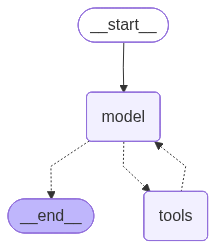

In [7]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [8]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (81df181b-902b-42ff-89fa-4a118b91d8f7)
 Call ID: 81df181b-902b-42ff-89fa-4a118b91d8f7
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (23ebf25d-7b6e-4e67-9f22-48cfab5f1695)
 Call ID: 23ebf25d-7b6e-4e67-9f22-48cfab5f1695
  Args:
    query: SELECT 'Album' AS table_name, COUNT(*) AS row_count FROM Album UNION ALL SELECT 'Artist', COUNT(*) FROM Artist UNION ALL SELECT 'Cust

In [9]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (5acedc65-8eea-4c0a-a63d-27342a1c1e45)
 Call ID: 5acedc65-8eea-4c0a-a63d-27342a1c1e45
  Args:
    query: SELECT T1.name, AVG(T2.duration) FROM genres AS T1 INNER JOIN tracks AS T2 ON T1.genre_id = T2.genre_id GROUP BY T1.name ORDER BY AVG(T2.duration) DESC LIMIT 1
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: genres
[SQL: SELECT T1.name, AVG(T2.duration) FROM genres AS T1 INNER JOIN tracks AS T2 ON T1.genre_id = T2.genre_id GROUP BY T1.name ORDER BY AVG(T2.duration) DESC LIMIT 1]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  execute_sql (4d58536

In [10]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (4ed8312d-dcc1-47cc-ba53-9bfa268c5a56)
 Call ID: 4ed8312d-dcc1-47cc-ba53-9bfa268c5a56
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

The tables in the database are:

*   Album
*   Artist
*   Customer
*   Employee
*   Genre
*   Invoice
*   InvoiceLine
*   MediaType
*   Playlist
*   PlaylistTrack
*   Track


**Create your own query here!**  Add some questions of your own.

In [11]:
question = "TRY YOUR OWN QUERY HERE"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

TRY YOUR OWN QUERY HERE
================================== Ai Message ==================================
Tool Calls:
  execute_sql (5f35cc63-8d90-4f8a-9008-b1c4c21ee460)
 Call ID: 5f35cc63-8d90-4f8a-9008-b1c4c21ee460
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (6ab19786-bec1-4a6a-9700-d1220799a585)
 Call ID: 6ab19786-bec1-4a6a-9700-d1220799a585
  Args:
    query: SELECT name FROM Customer LIMIT 5; SELECT name FROM Artist LIMIT 5;
================================= Tool Message =================================
Name: e

### Let's try this Studio